<a href="https://colab.research.google.com/github/theo-mattsa/Hands-On-Machine-Learning/blob/main/ExercisesChapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [3]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

In [8]:
# The MNIST dataset returned by fetch_openml is actually already split
X_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

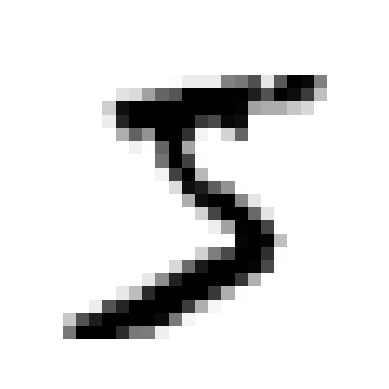

In [7]:
def plot_digit(image_data: np.ndarray):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap='binary')
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set.

**Hint:** the KNeighborsClassifier works quite well for this task; you just need to find good hyperparameter values (try a grid search on the weights and n_neighbors hyperparameters).

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

neigh = KNeighborsClassifier()
neigh.fit(X_train, y_train)

baseline_accuracy = neigh.score(x_test, y_test)
print(f"Baseline accuracy: {baseline_accuracy}")

Baseline accuracy: 0.9688


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'n_neighbors': [3, 4, 5, 6, 7, 8], 'weights': ['uniform', 'distance']}]
neigh = KNeighborsClassifier()

grid_search = GridSearchCV(neigh, param_grid, cv=5)
grid_search.fit(X_train[:10_000], y_train[:10_000])

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5, 6, 7, 8],
                          'weights': ['uniform', 'distance']}])

In [23]:
grid_search.best_score_

np.float64(0.9441999999999998)

In [24]:
grid_search.best_estimator_

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [25]:
grid_search.best_estimator_.fit(X_train, y_train)
accuracy = grid_search.best_estimator_.score(x_test, y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9714
